# WEEK 1 : Data Collection, Text Cleaning, and EDA

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("NYC311data.csv", nrows = 10000)
df

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01-01-16 7:43,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01-01-16 3:24,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32242311,12/20/2015 05:35:22 PM,12/20/2015 07:38:43 PM,NYPD,New York City Police Department,Illegal Parking,Double Parked Blocking Vehicle,Street/Sidewalk,10029.0,1760 3 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.786143,-73.948646,"(40.78614262952058, -73.94864628750543)"
9996,32240903,12/20/2015 05:33:03 PM,12/21/2015 02:01:44 AM,NYPD,New York City Police Department,Blocked Driveway,Partial Access,Street/Sidewalk,11226.0,931 OCEAN AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.639955,-73.959078,"(40.639955333814946, -73.95907837917537)"
9997,32241322,12/20/2015 05:32:39 PM,12/20/2015 06:19:47 PM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11218.0,1343 40 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.639476,-73.985879,"(40.6394759209015, -73.98587913404236)"
9998,32240998,12/20/2015 05:30:31 PM,12/20/2015 06:41:50 PM,NYPD,New York City Police Department,Homeless Encampment,NaN,Street/Sidewalk,10036.0,432 WEST 45 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.760913,-73.992578,"(40.76091321982277, -73.99257835358914)"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      10000 non-null  int64  
 1   Created Date                    10000 non-null  object 
 2   Closed Date                     9943 non-null   object 
 3   Agency                          10000 non-null  object 
 4   Agency Name                     10000 non-null  object 
 5   Complaint Type                  10000 non-null  object 
 6   Descriptor                      9822 non-null   object 
 7   Location Type                   10000 non-null  object 
 8   Incident Zip                    9934 non-null   float64
 9   Incident Address                8893 non-null   object 
 10  Street Name                     8893 non-null   object 
 11  Cross Street 1                  8752 non-null   object 
 12  Cross Street 2                  8

In [4]:
df.isnull().sum()

Unique Key                            0
Created Date                          0
Closed Date                          57
Agency                                0
Agency Name                           0
Complaint Type                        0
Descriptor                          178
Location Type                         0
Incident Zip                         66
Incident Address                   1107
Street Name                        1107
Cross Street 1                     1248
Cross Street 2                     1264
Intersection Street 1              8899
Intersection Street 2              8913
Address Type                         72
City                                 66
Landmark                           9994
Facility Type                        55
Status                                0
Due Date                              0
Resolution Description                0
Resolution Action Updated Date       55
Community Board                       0
Borough                               0


In [5]:
df['Complaint Type'].unique()

array(['Noise - Street/Sidewalk', 'Blocked Driveway', 'Illegal Parking',
       'Derelict Vehicle', 'Noise - Commercial',
       'Noise - House of Worship', 'Posting Advertisement',
       'Noise - Vehicle', 'Animal Abuse', 'Vending', 'Traffic',
       'Drinking', 'Bike/Roller/Skate Chronic', 'Panhandling',
       'Noise - Park', 'Homeless Encampment', 'Urinating in Public',
       'Graffiti', 'Disorderly Youth'], dtype=object)

In [6]:
df = df[['Complaint Type','Descriptor','Borough','Agency Name']]
print(df)
df.shape

               Complaint Type                      Descriptor    Borough  \
0     Noise - Street/Sidewalk                Loud Music/Party  MANHATTAN   
1            Blocked Driveway                       No Access     QUEENS   
2            Blocked Driveway                       No Access      BRONX   
3             Illegal Parking    Commercial Overnight Parking      BRONX   
4             Illegal Parking                Blocked Sidewalk     QUEENS   
...                       ...                             ...        ...   
9995          Illegal Parking  Double Parked Blocking Vehicle  MANHATTAN   
9996         Blocked Driveway                  Partial Access   BROOKLYN   
9997         Blocked Driveway                       No Access   BROOKLYN   
9998      Homeless Encampment                             NaN  MANHATTAN   
9999          Illegal Parking   Posted Parking Sign Violation  MANHATTAN   

                          Agency Name  
0     New York City Police Department  
1     N

(10000, 4)

In [7]:
df = df.dropna(subset = ['Descriptor','Complaint Type'])
df.shape

(9822, 4)

In [8]:
df = df[df['Borough'] != 'Unspecified']
print("Shape after removing Unspecified borough:", df.shape)

Shape after removing Unspecified borough: (9756, 4)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

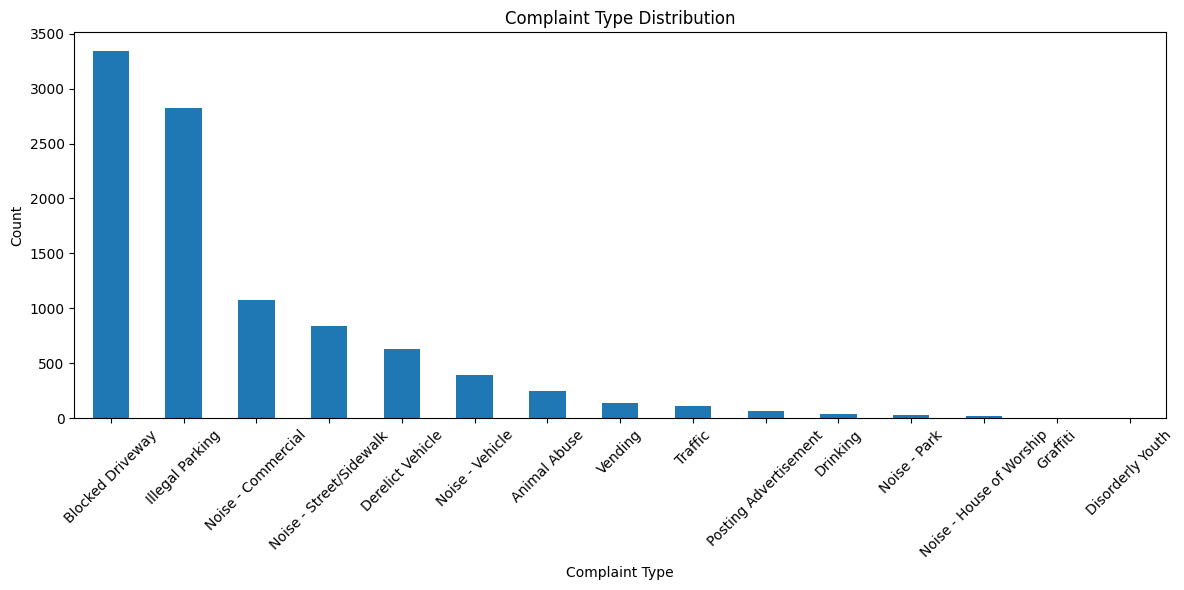

In [10]:
df['Complaint Type'].value_counts().plot(kind = 'bar', figsize = (12,6))
plt.title('Complaint Type Distribution')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
top10 = df['Complaint Type'].value_counts().head(10).index
df = df[df['Complaint Type'].isin(top10)]
df['Complaint Type'].value_counts()

Complaint Type
Blocked Driveway           3345
Illegal Parking            2825
Noise - Commercial         1077
Noise - Street/Sidewalk     836
Derelict Vehicle            630
Noise - Vehicle             390
Animal Abuse                249
Vending                     137
Traffic                     110
Posting Advertisement        62
Name: count, dtype: int64

In [12]:
df['Text_length'] = df['Descriptor'].apply(len)
df['Text_length'].describe()

count    9661.000000
mean       15.955595
std         6.802325
min         6.000000
25%         9.000000
50%        15.000000
75%        18.000000
max        30.000000
Name: Text_length, dtype: float64

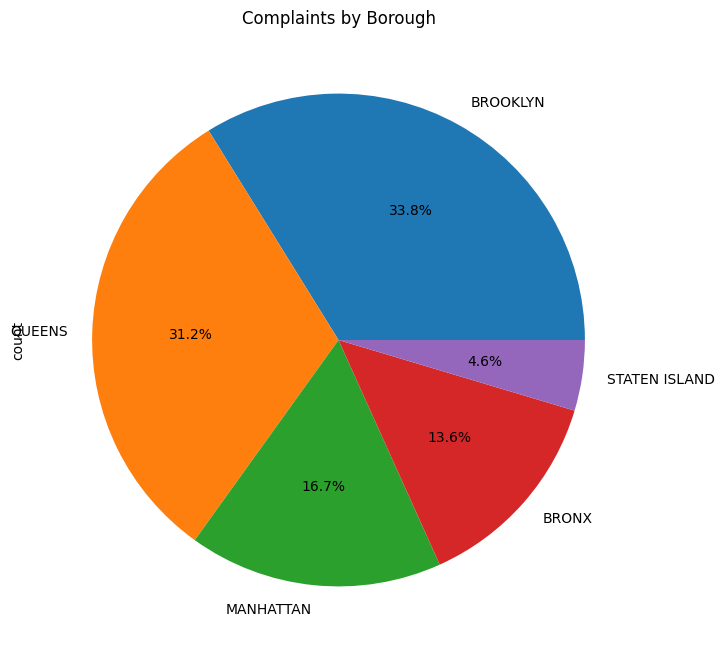

In [13]:
df['Borough'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('Complaints by Borough')
plt.show()

In [14]:
df['clean_text'] = df['Descriptor'].str.lower()

In [15]:
import re
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [16]:
df.head(10)

,Complaint Type,Descriptor,Borough,Agency Name,Text_length,clean_text
0,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,New York City Police Department,16,loud musicparty
1,Blocked Driveway,No Access,QUEENS,New York City Police Department,9,no access
2,Blocked Driveway,No Access,BRONX,New York City Police Department,9,no access
3,Illegal Parking,Commercial Overnight Parking,BRONX,New York City Police Department,28,commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,QUEENS,New York City Police Department,16,blocked sidewalk
5,Illegal Parking,Posted Parking Sign Violation,BROOKLYN,New York City Police Department,29,posted parking sign violation
6,Illegal Parking,Blocked Hydrant,MANHATTAN,New York City Police Department,15,blocked hydrant
7,Blocked Driveway,No Access,BRONX,New York City Police Department,9,no access
8,Illegal Parking,Posted Parking Sign Violation,QUEENS,New York City Police Department,29,posted parking sign violation
9,Blocked Driveway,No Access,BROOKLYN,New York City Police Department,9,no access


In [17]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\RAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
negations = {'no', 'not', 'never', 'neither', 'nor'}
stop_words = stop_words - negations

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [19]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

In [20]:
df[['Descriptor', 'clean_text']].head(10)

,Descriptor,clean_text
0,Loud Music/Party,loud musicparty
1,No Access,no access
2,No Access,no access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,blocked sidewalk
5,Posted Parking Sign Violation,posted parking sign violation
6,Blocked Hydrant,blocked hydrant
7,No Access,no access
8,Posted Parking Sign Violation,posted parking sign violation
9,No Access,no access


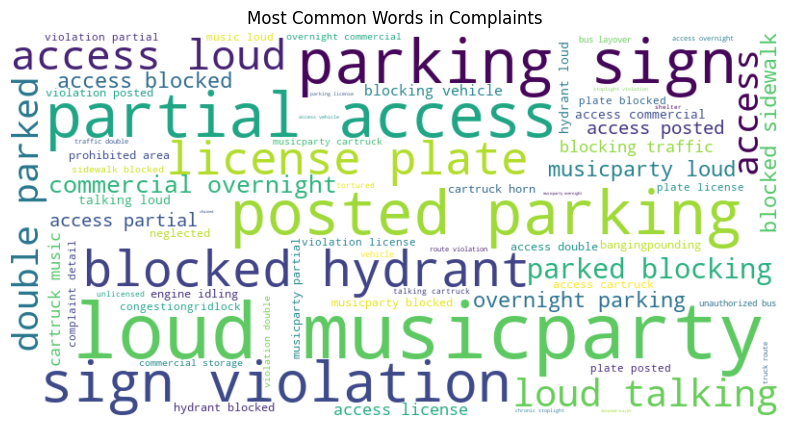

In [21]:
from wordcloud import WordCloud

text = ' '.join(df['clean_text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Complaints')
plt.show()

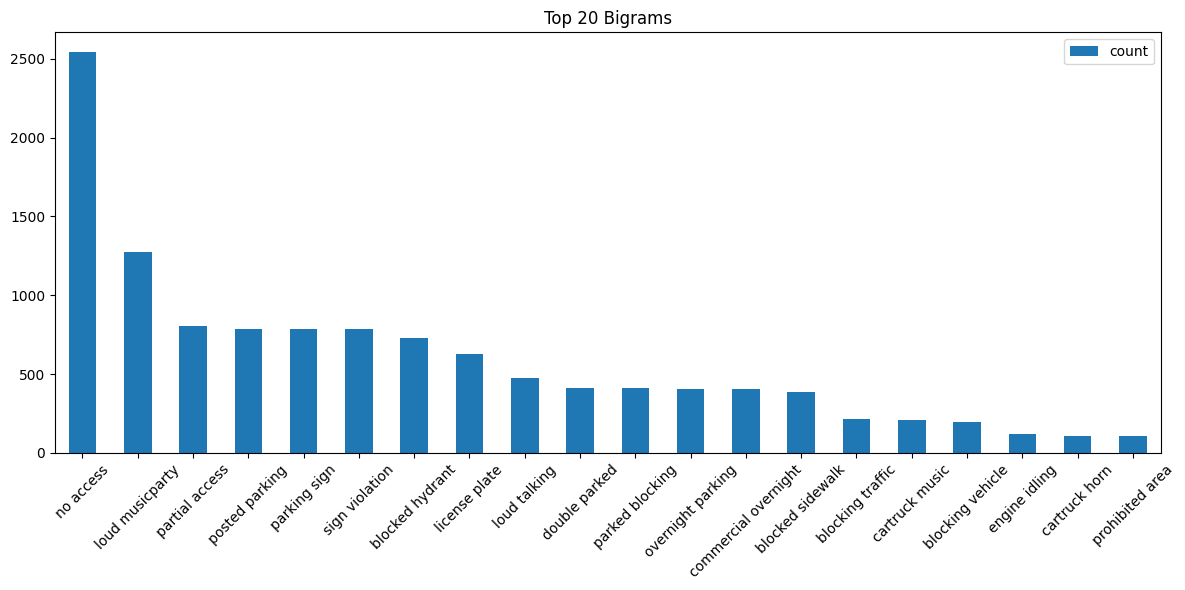

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['clean_text'])

bigram_df = pd.DataFrame(X.toarray().sum(axis=0),index=vectorizer.get_feature_names_out(),columns=['count']).sort_values('count', ascending=False)

bigram_df.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Bigrams')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()